In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('/content/data_science_job.csv')

df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [13]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [11]:
cols=[var for var in df.columns if df[var].isnull().mean() < 0.05  and df[var].isnull().mean() > 0 ]

In [14]:
df.shape

(19158, 13)

In [12]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [17]:
df[cols].sample(4)

,city_development_index,enrolled_university,education_level,experience,training_hours
12617,NaN,no_enrollment,Graduate,4.0,19.0
18024,0.920,no_enrollment,Graduate,8.0,54.0
3347,0.926,no_enrollment,High School,5.0,56.0
5177,0.624,no_enrollment,Graduate,20.0,26.0


In [18]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [19]:
new_df=df[cols].dropna()

df.shape , new_df.shape

((19158, 13), (17182, 5))

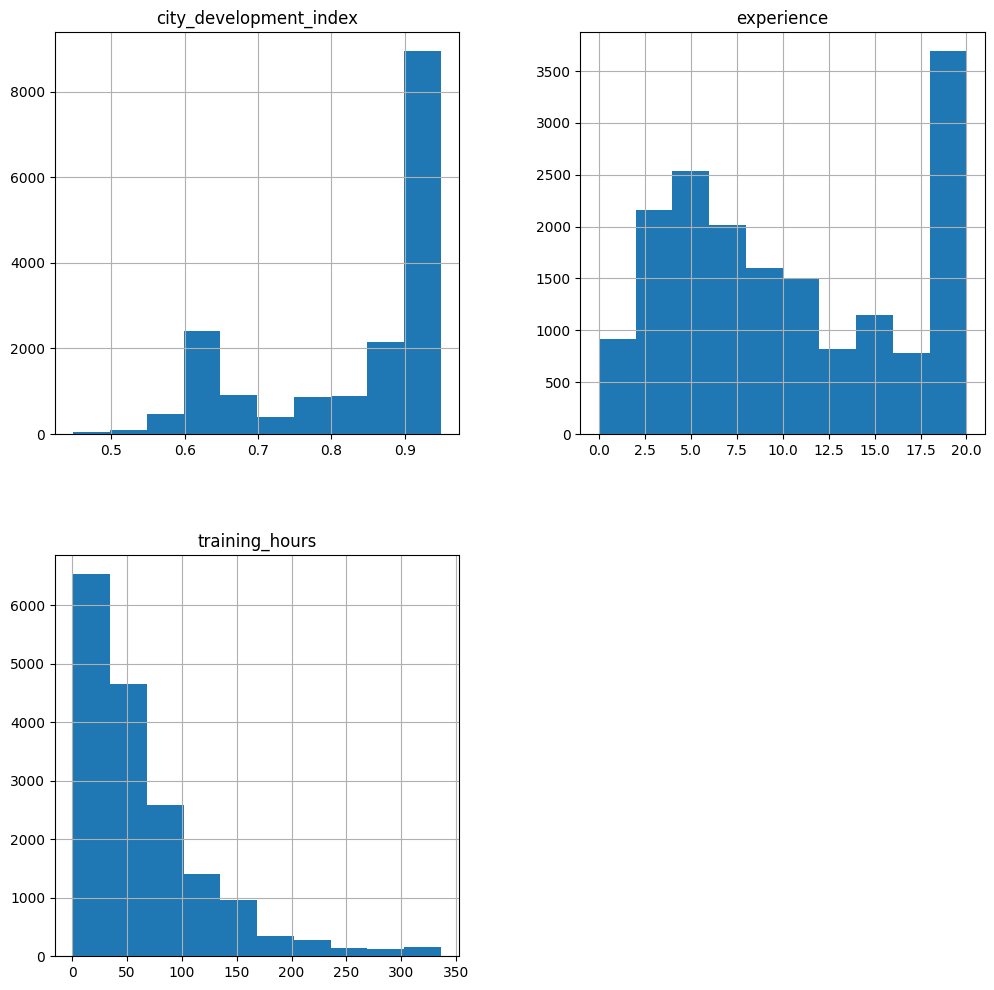

In [20]:
new_df.hist(bins=10,figsize=(12,12))
plt.show()

<Axes: >

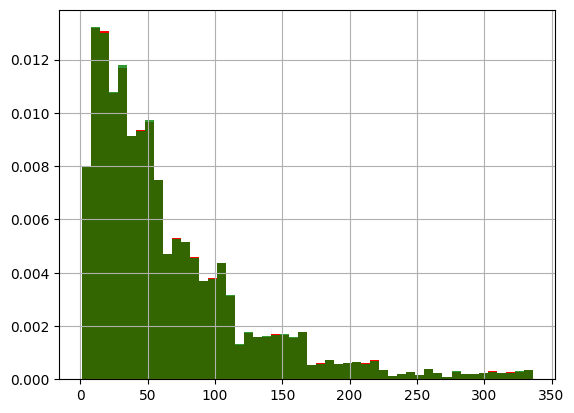

In [27]:
fig=plt.figure()
ax=fig.add_subplot(111)

df['training_hours'].hist(bins=50,ax=ax,color='red',density=True)

new_df['training_hours'].hist(bins=50,ax=ax,alpha=0.8,color='green',density=True)

<Axes: ylabel='Density'>

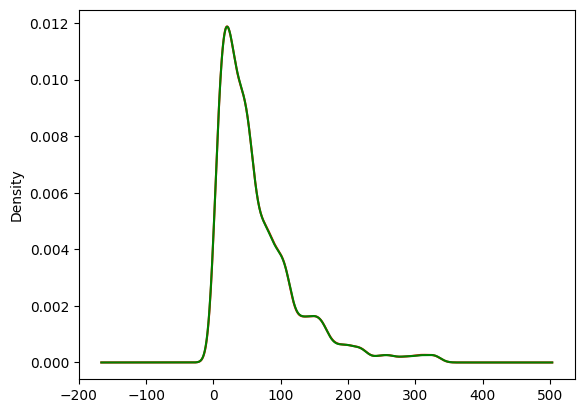

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

<Axes: >

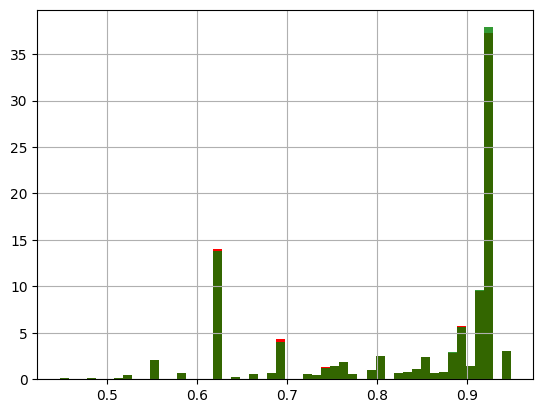

In [28]:
fig=plt.figure()
ax=fig.add_subplot(111)

df['city_development_index'].hist(bins=50,ax=ax,color='red',density=True)

new_df['city_development_index'].hist(bins=50,ax=ax,alpha=0.8,color='green',density=True)

<Axes: ylabel='Density'>

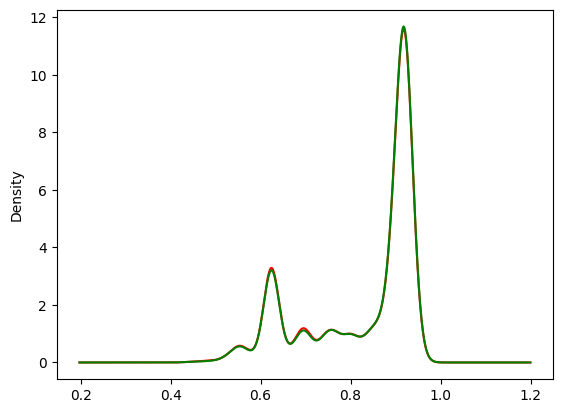

In [30]:

fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')

<Axes: >

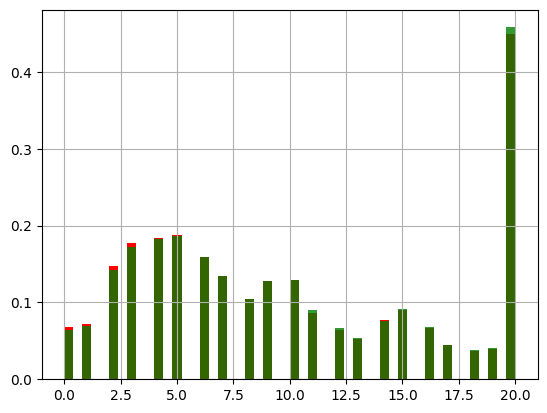

In [32]:

fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

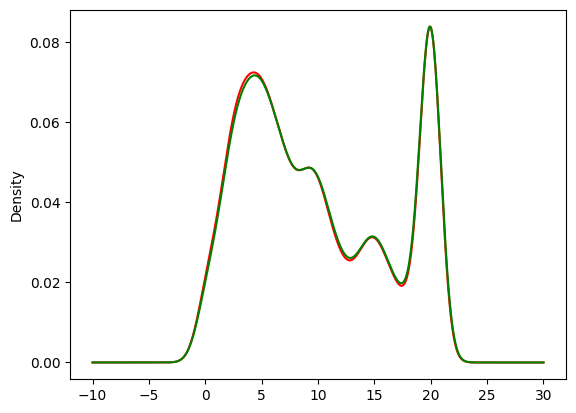

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')

In [35]:
temp=pd.concat([
    df['enrolled_university'].value_counts()/len(df),

    new_df['enrolled_university'].value_counts()/len(new_df)
],axis=1)

temp.columns=['original','cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [36]:
temp1=pd.concat([
    df['education_level'].value_counts()/len(df),

    new_df['education_level'].value_counts()/len(new_df)
],axis=1)

temp1.columns=['original','cca']

temp1

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
